# Weather analysis

How temperature, humidity, and wind relate to NO₂ and PM2.5

In [40]:

try:
    from google.colab import files
    uploaded = files.upload()          # select open_air_hour_aggregations.CSV
    FNAME = list(uploaded.keys())[0]
except Exception:
    FNAME = "recipe2.csv"              # fallback if running locally

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(FNAME)
df.columns = [c.strip() for c in df.columns]
print(df.shape)
df.head()


Saving Open_Air_Chicago_Hour_Aggregations_20260927.csv to Open_Air_Chicago_Hour_Aggregations_20260927 (3).csv
(10259, 5)


,avg_no2conc1hourmean_value,startofperiod,avg_pm2_5concmass1hourmean_value,avg_pm2_5concmassnowcast_value,count_datasourceid
0,32.577500,07/26/2025 12:00:00 PM,8.415000,NaN,4
1,32.511667,07/26/2025 01:00:00 PM,7.138571,7.662500,7
2,25.385000,07/26/2025 02:00:00 PM,7.389167,7.262857,12
3,20.054000,07/26/2025 03:00:00 PM,7.518000,7.336667,15
4,18.179412,07/26/2025 04:00:00 PM,7.013529,7.209333,17


In [41]:
# 2) Tidy column names + convert time from UTC to Chicago local
df = df.rename(columns={
    'avg_no2conc1hourmean_value':      'no2',          # ppb
    'avg_pm2_5concmass1hourmean_value':'pm25',         # ug/m3 (1-hour)
    'avg_pm2_5concmassnowcast_value':  'pm25_nowcast', # ug/m3 (NowCast)
    'count_datasourceid':              'n_sensors',
})

# startofperiod is UTC -> convert to local so hour-of-day means Chicago time
t = pd.to_datetime(df['startofperiod'], format='%m/%d/%Y %I:%M:%S %p', utc=True)
df['time'] = t.dt.tz_convert('America/Chicago')
df = df.sort_values('time').reset_index(drop=True)
df['hour'] = df['time'].dt.hour          # 0-23 local
df['dow']  = df['time'].dt.dayofweek     # 0=Mon ... 6=Sun

print('range:', df['time'].min(), '->', df['time'].max())
print('hours:', len(df))
df[['time','no2','pm25','pm25_nowcast','n_sensors']].head()


range: 2025-07-26 07:00:00-05:00 -> 2026-09-26 18:00:00-05:00
hours: 10259


,time,no2,pm25,pm25_nowcast,n_sensors
0,2025-07-26 07:00:00-05:00,32.577500,8.415000,NaN,4
1,2025-07-26 08:00:00-05:00,32.511667,7.138571,7.662500,7
2,2025-07-26 09:00:00-05:00,25.385000,7.389167,7.262857,12
3,2025-07-26 10:00:00-05:00,20.054000,7.518000,7.336667,15
4,2025-07-26 11:00:00-05:00,18.179412,7.013529,7.209333,17


## Autocorrelation (justifies using lag features)

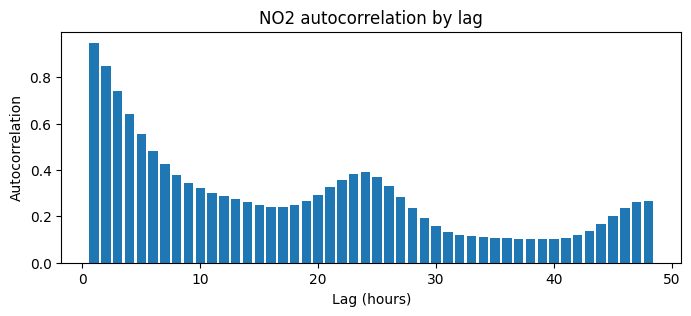

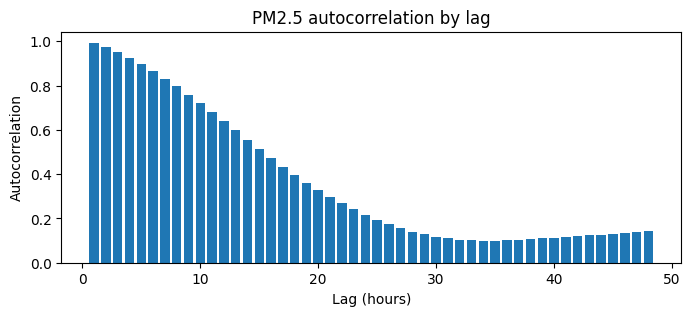

In [42]:
# 9) How strongly each hour relates to previous hours.
# A tall bar at lag 1 = recent value predicts next value; a bump at lag 24 = daily cycle.
def autocorr_plot(series, title):
    s = series.asfreq('h')          # regular hourly spacing
    lags = range(1, 49)
    ac = [s.autocorr(lag=k) for k in lags]
    plt.figure(figsize=(8,3))
    plt.bar(list(lags), ac)
    plt.xlabel('Lag (hours)')
    plt.ylabel('Autocorrelation')
    plt.title(title)
    plt.show()

s = df.set_index('time')
autocorr_plot(s['no2'],          'NO2 autocorrelation by lag')
autocorr_plot(s['pm25_nowcast'], 'PM2.5 autocorrelation by lag')


In [43]:
import requests, pandas as pd

# date range straight from your data (UTC)
start_date = df['time'].min().tz_convert('UTC').strftime('%Y-%m-%d')
end_date   = df['time'].max().tz_convert('UTC').strftime('%Y-%m-%d')

params = {
    "latitude": 41.9803, "longitude": -87.9090,   # O'Hare
    "start_date": start_date, "end_date": end_date,
    "hourly": "temperature_2m,relative_humidity_2m,wind_speed_10m,wind_direction_10m,precipitation,surface_pressure",
    "timezone": "UTC",
}
r = requests.get("https://archive-api.open-meteo.com/v1/archive", params=params, timeout=60).json()

wx = pd.DataFrame(r["hourly"])
wx["time_utc"] = pd.to_datetime(wx["time"])   # UTC, tz-naive
wx = wx.rename(columns={
    "temperature_2m":"temp", "relative_humidity_2m":"rhum",
    "wind_speed_10m":"wspd", "wind_direction_10m":"wdir",
    "precipitation":"prcp", "surface_pressure":"pres",
})
print(wx.shape)
wx.head()

(10272, 8)


,time,temp,rhum,wspd,wdir,prcp,pres,time_utc
0,2025-07-26T00:00,24.4,87,7.4,58,0.0,992.4,2025-07-26 00:00:00
1,2025-07-26T01:00,23.6,91,5.9,50,0.0,993.3,2025-07-26 01:00:00
2,2025-07-26T02:00,22.9,94,4.8,56,0.0,993.9,2025-07-26 02:00:00
3,2025-07-26T03:00,22.3,96,5.9,55,0.0,993.9,2025-07-26 03:00:00
4,2025-07-26T04:00,22.2,95,4.5,47,0.0,994.1,2025-07-26 04:00:00


In [44]:
# rebuild a UTC key on the air side (join on UTC, not local -> avoids DST issues)
df['time_utc'] = df['time'].dt.tz_convert('UTC').dt.tz_localize(None)

keep = ['time_utc','temp','rhum','wspd','wdir','prcp','pres']  # C, %, km/h, deg, mm, hPa
df = df.merge(wx[keep], on='time_utc', how='left')

print('weather matched:', df['wspd'].notna().sum(), '/', len(df))
df[['time','no2','pm25_nowcast','temp','wspd','wdir']].head()

weather matched: 10259 / 10259


,time,no2,pm25_nowcast,temp,wspd,wdir
0,2025-07-26 07:00:00-05:00,32.577500,NaN,23.3,5.2,214
1,2025-07-26 08:00:00-05:00,32.511667,7.662500,23.1,7.7,179
2,2025-07-26 09:00:00-05:00,25.385000,7.262857,25.3,11.2,226
3,2025-07-26 10:00:00-05:00,20.054000,7.336667,25.4,9.6,237
4,2025-07-26 11:00:00-05:00,18.179412,7.209333,25.3,12.0,206


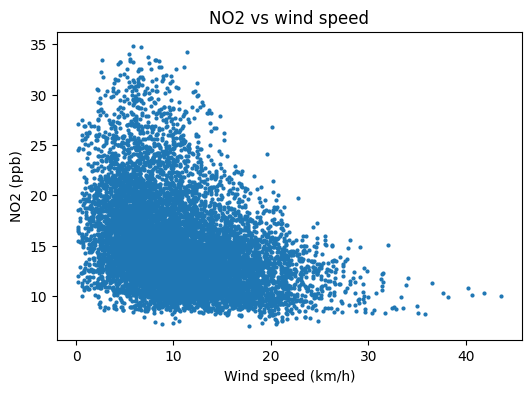

In [45]:
import matplotlib.pyplot as plt
plt.figure(figsize=(6,4))
plt.scatter(df['wspd'], df['no2'], s=4)
plt.xlabel('Wind speed (km/h)')
plt.ylabel('NO2 (ppb)')
plt.title('NO2 vs wind speed')
plt.show()

At low wind (0–5 km/h) NO₂ ranges all the way up to ~35 ppb; once wind climbs past ~20 km/h it's squeezed down to ~8–15. Higher wind blows the pollution away, causing \[NO_{2}\] levels to drop. Low wind traps pollution in the air, making \[NO_{2}\] go up.


In [46]:
df['no2'].corr(df['wspd'])

np.float64(-0.3662605046132747)

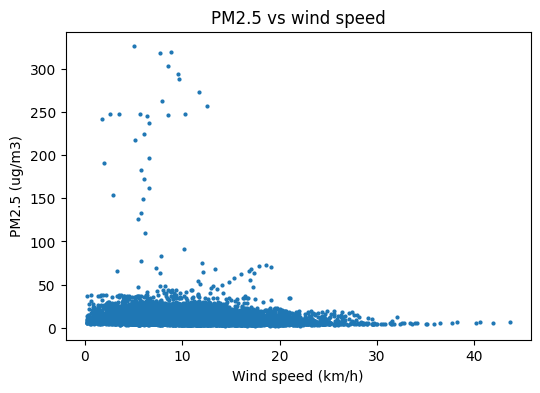

-0.12320830188105276


In [47]:
# scatter: PM2.5 vs wind
plt.figure(figsize=(6,4))
plt.scatter(df['wspd'], df['pm25_nowcast'], s=4)
plt.xlabel('Wind speed (km/h)')
plt.ylabel('PM2.5 (ug/m3)')
plt.title('PM2.5 vs wind speed')
plt.show()

# correlation number
print(df['pm25_nowcast'].corr(df['wspd']))

This is a very week negative correlation. the conclusion is that PM2.5 is largely independent of wind speed.

In [48]:
df[['no2','pm25_nowcast','temp','rhum','wspd']].corr().round(2)

,no2,pm25_nowcast,temp,rhum,wspd
no2,1.00,0.13,-0.29,0.24,-0.37
pm25_nowcast,0.13,1.00,0.09,0.05,-0.12
temp,-0.29,0.09,1.00,-0.17,-0.13
rhum,0.24,0.05,-0.17,1.00,-0.16
wspd,-0.37,-0.12,-0.13,-0.16,1.00


In [49]:
import statsmodels.formula.api as smf
m = smf.ols('no2 ~ temp + rhum + wspd', data=df).fit()
print(m.rsuffix if False else m.summary().tables[1]); print('R2:', round(m.rsquared,3))

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     17.6978      0.208     85.071      0.000      17.290      18.106
temp          -0.1231      0.003    -37.140      0.000      -0.130      -0.117
rhum           0.0330      0.002     14.557      0.000       0.029       0.037
wspd          -0.3245      0.007    -44.884      0.000      -0.339      -0.310
R2: 0.267


In [50]:
import statsmodels.formula.api as smf
m = smf.ols('pm25_nowcast ~ temp + rhum + wspd', data=df).fit()
print(m.summary().tables[1]); print('R2:', round(m.rsquared,3))

                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      9.9124      0.735     13.479      0.000       8.471      11.354
temp           0.0951      0.012      8.114      0.000       0.072       0.118
rhum           0.0406      0.008      5.066      0.000       0.025       0.056
wspd          -0.2657      0.026    -10.398      0.000      -0.316      -0.216
R2: 0.023


Weather explains ~27% of NO₂ but only ~2% of PM2.5 — NO₂ is local and weather-sensitive, PM2.5 is regional smoke.

In [51]:
import numpy as np, pandas as pd
from scipy import stats

d = df[(df['time'] >= '2025-09-01') & (df['dow'] < 5)].copy()   # analysis window, weekdays
d['date'] = d['time'].dt.date

# hour-of-day profile + windows
prof = d.groupby('hour')['no2'].mean()
print("peak hour", prof.idxmax(), round(prof.max(),1), "| trough hour", prof.idxmin(), round(prof.min(),1))
for name, m in [('morning 7-9', d['hour'].between(7,9)), ('midday 11-14', d['hour'].between(11,14)),
                ('evening 16-18', d['hour'].between(16,18)), ('overnight 0-5', d['hour'].between(0,5))]:
    print(f"{name:14s}: {d.loc[m,'no2'].mean():.1f} ppb")

peak hour 7 18.8 | trough hour 13 13.3
morning 7-9   : 17.3 ppb
midday 11-14  : 13.4 ppb
evening 16-18 : 14.9 ppb
overnight 0-5 : 16.4 ppb


In [52]:
# honest test at the DAY level: morning rush vs midday (each day = one pair)
d['seg'] = np.select([d['hour'].between(7,9), d['hour'].between(11,14)], ['morning','midday'], default='other')
pair = d[d.seg.isin(['morning','midday'])].pivot_table(index='date', columns='seg', values='no2', aggfunc='mean').dropna()
diff = pair['morning'] - pair['midday']; n = len(pair)
md, d_cohen = diff.mean(), diff.mean()/diff.std(ddof=1)
ci = stats.t.interval(0.95, n-1, loc=md, scale=stats.sem(diff))
t, p = stats.ttest_rel(pair['morning'], pair['midday'])
print(f"days={n}  morning-midday diff={md:.2f} ppb  95% CI {ci[0]:.2f}..{ci[1]:.2f}")
print(f"Cohen's d={d_cohen:.2f}  (paired t={t:.1f}, p={p:.1e} — but judge by d, not p)")

days=280  morning-midday diff=3.87 ppb  95% CI 3.49..4.25
Cohen's d=1.20  (paired t=20.2, p=2.4e-56 — but judge by d, not p)


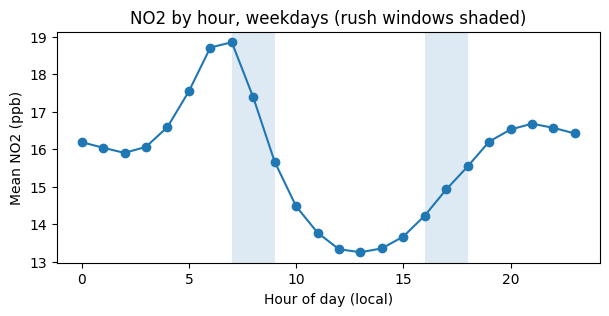

In [53]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,3))
plt.plot(prof.index, prof.values, marker='o')
plt.axvspan(7,9, alpha=0.15); plt.axvspan(16,18, alpha=0.15)
plt.xlabel('Hour of day (local)'); plt.ylabel('Mean NO2 (ppb)')
plt.title('NO2 by hour, weekdays (rush windows shaded)')
plt.show()

Conclusion: NO₂ shows a strong, statistically and practically significant morning rush-hour spike (≈4 ppb above midday, d ≈ 1.2). overnight NO₂ is high (16.4), and not from traffic. NO₂ doesn't show a strong evening traffic peak. a coarse rush-vs-offpeak contrast understates the morning effect. AQI itself shows no rush-hour pattern, since AQI is PM2.5-driven.

wind_dir
N     14.3
NE    12.8
E     14.0
SE    16.6
S     16.5
SW    16.1
W     15.0
NW    15.2
Name: no2, dtype: float64


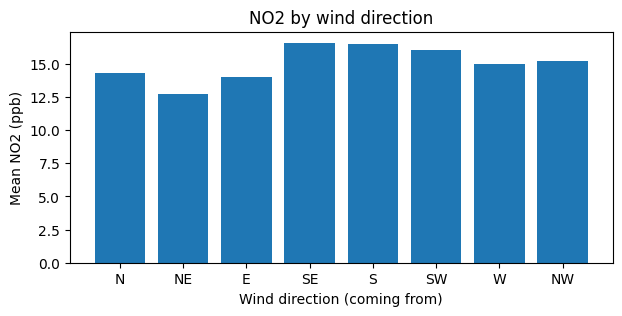

In [54]:
# NO2 by wind direction — which way is the dirty air coming from?
# Open-Meteo wdir = the direction wind blows FROM (0=N, 90=E, 180=S, 270=W)
dirs = ['N','NE','E','SE','S','SW','W','NW']
sec = (((df['wdir'] + 22.5) // 45) % 8).astype(int)
df['wind_dir'] = sec.map(dict(enumerate(dirs)))

no2_by_dir = df.groupby('wind_dir')['no2'].mean().reindex(dirs)
print(no2_by_dir.round(1))

import matplotlib.pyplot as plt
plt.figure(figsize=(7,3))
plt.bar(dirs, no2_by_dir.values)
plt.xlabel('Wind direction (coming from)')
plt.ylabel('Mean NO2 (ppb)')
plt.title('NO2 by wind direction')
plt.show()

wind_dir
N     10.6
NE    13.3
E     11.2
SE    12.4
S     11.9
SW    11.8
W      9.5
NW     8.7
Name: pm25_nowcast, dtype: float64


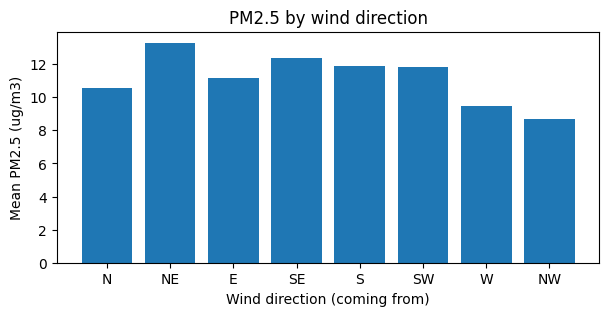

In [55]:
pm_by_dir = df.groupby('wind_dir')['pm25_nowcast'].mean().reindex(dirs)
print(pm_by_dir.round(1))
plt.figure(figsize=(7,3))
plt.bar(dirs, pm_by_dir.values)
plt.xlabel('Wind direction (coming from)')
plt.ylabel('Mean PM2.5 (ug/m3)')
plt.title('PM2.5 by wind direction')
plt.show()

NO₂ is highest on southerly winds (S/SE/SW, ~16.5 ppb) and lowest off the lake (NE, 12.8) — matching the industrial South/SW-Side sources.

PM2.5 shows the opposite, peaking on easterly/regional winds, which again points to NO₂ being local and PM2.5 regional. Differences are modest and partly confounded with wind speed (and, for PM2.5, lake-air humidity).

QUESTIONS TO ANSWER NEXT:
- Compare AQI or particulate matter (\[PM_{2.5}\]) levels between Chicago's industrial South/West sides and the North side to analyze socioeconomic air quality disparities.
- Analyze the "Canadian wildfire effect" by comparing Chicago's AQI data from recent years (like 2023–2025) against a historical baseline to quantify the statistical significance of these extreme anomalies. This is to confirm if they are extreme outliers and decide if they should be kept in the data or not.